# Phase C Baseline Ladder
Reports the baselines Phase D has to beat. The phase is built as a decomposition rather than a
horse race, so adjacent rungs differ in one respect each and Phase D's eventual margin can be
attributed rather than only observed. Every number is read from the committed artifacts in
results/phase_c and nothing is recomputed here.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import c1_trailing, c3_gbm, claim1_eval

## Configuration
Artifact location, display settings, and the orderings used for every table below. The
artifacts are regenerated by the single seeded command `python -m src.analysis.c_report`.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)

RESULTS_DIR = REPO_ROOT / "results/phase_c"

MODEL_ORDER = ["no_info_league_average", "c1_raw", "c1_bucketed", "c2_bivariate",
               "c2_book_rho_reference", "c3_gbm_outcome", "c3_gbm_full"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load(name):
    """Read one committed Phase C artifact by filename."""
    return pd.read_csv(RESULTS_DIR / name)

## Run parameters read from their owner modules
Every threshold is imported rather than retyped, so a moved constant breaks this cell instead
of quietly making the writeup wrong.

In [3]:
pd.Series({
    "trailing window, seasons": c1_trailing.TRAILING_SEASONS,
    "C.1 shrinkage buckets": str(c1_trailing.PA_BUCKETS),
    "stabilization anchor n* from B.1": claim1_eval.STABILIZATION_N_STAR,
    "stratum boundaries in prior PA": str(claim1_eval.STRATUM_BOUNDARIES),
    "eval season PA floor": claim1_eval.MIN_EVAL_PA,
    "committed sensitivity sweep": str(claim1_eval.MIN_EVAL_PA_SENSITIVITY),
    "C.3 inner val season": c3_gbm.INNER_VAL_SEASON,
    "C.3 early stopping rounds": c3_gbm.EARLY_STOPPING_ROUNDS,
}, name="value").to_frame()

,value
"trailing window, seasons",3
C.1 shrinkage buckets,"((0, 0.0), (50, 0.5), (200, 1.0))"
stabilization anchor n* from B.1,226
stratum boundaries in prior PA,"(113, 452)"
eval season PA floor,10
committed sensitivity sweep,"(10, 25, 50)"
C.3 inner val season,2023
C.3 early stopping rounds,50


## The ladder
Each rung differs from the one below it in exactly one respect, named in the right column.

| rung | what it is | what the step from below isolates |
|---|---|---|
| `no_info_league_average` | side specific league average | reference; its deconvolved error is the between hitter talent spread, so skill scores read as share of talent variance captured |
| `c1_raw` | trailing 3 season side specific wOBA, unshrunk | the hitter's own record with no regularization |
| `c1_bucketed` | same record, blended to league average by a step function of PA | the value of shrinkage at all |
| `c2_bivariate` | bivariate empirical Bayes, continuous shrinkage plus cross side borrowing via rho | the value of doing shrinkage properly |
| `c2_book_rho_reference` | the same machinery at The Book's published constants | the literal incumbent frozen rule 1 names |
| `c3_gbm_outcome` | XGBoost on exactly the features C.2 saw | the value of a flexible functional form, information held fixed |
| `c3_gbm_full` | plus process features and context slices | the value of extra information, model class held fixed |
| Phase D | conditional query DL, hitter embedding by pitch context | cross hitter parameter sharing conditioned on pitch context |

Frozen rule 1 is written in role matched terms, meaning the baselines are what a competent
analyst does today and the bar is practical. Section 4's feature decision rule is information
matched and isolates components instead. Phase C owns the first and Phase D owns the second.

## Eval frame coverage
Rows are batter by target season by pitcher hand, and strata are cut on prior side specific PA
at the B.1 anchor. The PA floor drops hitters whose held out wOBA is essentially random, but it
conditions on eval season playing time, which is decided after the projection and partly by how
the hitter performed, so its effect is reported per stratum rather than as a single count.

In [4]:
coverage = json.loads((RESULTS_DIR / "c_coverage.json").read_text())
for key, value in coverage.items():
    if key != "by_stratum":
        print(f"{key}: {value}")

eval_season: 2024
actual_groups: 1279
dropped_below_min_eval_pa: 130
min_eval_pa: 10
dropped_no_prediction: 0
scored_groups: 1149


In [5]:
stratum_coverage = pd.DataFrame(coverage["by_stratum"]).T.loc[["low", "medium", "high"]]
stratum_coverage["woba_gap_dropped_minus_scored"] = (
    stratum_coverage["mean_woba_dropped"] - stratum_coverage["mean_woba_scored"])
stratum_coverage.round(3)

,scored,dropped,share_dropped,mean_woba_scored,mean_woba_dropped,woba_gap_dropped_minus_scored
low,380.0,85.0,0.183,0.272,0.198,-0.074
medium,280.0,33.0,0.105,0.286,0.225,-0.062
high,489.0,12.0,0.024,0.304,0.173,-0.131


## Absolute scores on the frozen RMSE metric
PA weighted RMSE by model and stratum, which is the frozen section 5.2 number. These are read
straight from the scores artifact and no comparison is claimed from them.

In [6]:
scores = load("c_claim1_scores.csv")
scores["model"] = pd.Categorical(scores["model"], MODEL_ORDER, ordered=True)
scores["stratum"] = pd.Categorical(scores["stratum"], STRATUM_ORDER, ordered=True)
scores.pivot(index="model", columns="stratum", values="pa_weighted_rmse").round(5)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.06310,0.05142,0.04795,0.05171
c1_raw,0.10542,0.06380,0.04312,0.06316
c1_bucketed,0.06598,0.05852,0.04315,0.05131
c2_bivariate,0.06176,0.05062,0.04105,0.04743
c2_book_rho_reference,0.06198,0.05017,0.04100,0.04736
c3_gbm_outcome,0.05943,0.05021,0.04096,0.04676
c3_gbm_full,0.05868,0.04949,0.04081,0.04634


## Skill scores against the no information reference
The same errors expressed as the share of between hitter talent variance each model captures.
Negative means worse than predicting the side specific league average for everyone.

In [7]:
scores.pivot(index="model", columns="stratum", values="skill_vs_no_info").round(3)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.000,0.000,0.000,0.000
c1_raw,-5.183,-1.743,0.371,-1.149
c1_bucketed,-0.271,-0.954,0.369,0.036
c2_bivariate,0.122,0.099,0.518,0.371
c2_book_rho_reference,0.102,0.154,0.522,0.376
c3_gbm_outcome,0.327,0.150,0.524,0.426
c3_gbm_full,0.391,0.238,0.535,0.460


## Rank correlation by model and stratum
The second frozen metric. It is unweighted, so a 10 PA row gets the same vote as a 400 PA
regular, which makes it the noisier of the two.

In [8]:
scores.pivot(index="model", columns="stratum", values="rank_corr").round(3)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.002,0.047,0.115,0.013
c1_raw,0.114,0.154,0.445,0.276
c1_bucketed,0.016,0.152,0.442,0.258
c2_bivariate,0.114,0.251,0.485,0.328
c2_book_rho_reference,0.103,0.268,0.492,0.332
c3_gbm_outcome,0.111,0.211,0.481,0.344
c3_gbm_full,0.129,0.257,0.498,0.370


## Noise floor share of squared error
The held out target is itself a small sample measurement, so errors add in quadrature and every
model pays the same irreducible tax. This is how much of the observed squared error that tax
accounts for, which is why no claim below rests on two absolute numbers.

In [9]:
floor = scores[scores["model"] == "no_info_league_average"]
floor.assign(floor_share_of_mse=lambda frame:
             frame["noise_floor"] ** 2 / frame["pa_weighted_rmse"] ** 2)[
    ["stratum", "n_hitters", "pa", "scoring_pa", "pa_weighted_rmse", "noise_floor",
     "model_rmse", "floor_share_of_mse"]].round(4)

,stratum,n_hitters,pa,scoring_pa,pa_weighted_rmse,noise_floor,model_rmse,floor_share_of_mse
16,low,380,33003.0,32781.0,0.0631,0.0510,0.0371,0.6544
17,medium,280,37072.0,36877.0,0.0514,0.0427,0.0286,0.6903
18,high,489,111752.0,111114.0,0.0479,0.0334,0.0344,0.4848
19,all,1149,181827.0,180772.0,0.0517,0.0391,0.0338,0.5720


## Paired RMSE head to heads
Two models scored against the same noisy answer key cannot be separated by their absolute
errors, so every head to head goes through a paired bootstrap of the difference. The resampling
unit is the batter rather than the batter by hand row, because a hitter's two rows share his
talent, health and park and are not independent draws.

In [10]:
PAIRED_FILES = {
    "C.2 minus C.1 raw": "c2_vs_c1_raw_paired.csv",
    "C.2 minus C.1 bucketed": "c2_vs_c1_bucketed_paired.csv",
    "C.2 minus C.2 at Book rho": "c2_vs_book_rho_paired.csv",
    "C.3 full minus C.2": "c3_vs_c2_paired.csv",
    "C.3 full minus C.3 outcome": "c3_process_ablation_paired.csv",
}
DIRECTIONAL_SHARE = 0.90


def verdict(row):
    """
    Classifies one paired bootstrap row. Established means the 95 percent interval excludes
    zero, directional means it does not but the bootstrap share is at least DIRECTIONAL_SHARE
    one way, and not resolved means neither.
    """
    if row["ci_low"] > 0 or row["ci_high"] < 0:
        return "established"
    if max(row["favours_a_share"], 1 - row["favours_a_share"]) >= DIRECTIONAL_SHARE:
        return "directional"
    return "not resolved"


paired_parts = []
for label, filename in PAIRED_FILES.items():
    part = load(filename).assign(comparison=label)
    part["verdict"] = part.apply(verdict, axis=1)
    paired_parts.append(part)

paired = pd.concat(paired_parts, ignore_index=True)
paired["stratum"] = pd.Categorical(paired["stratum"], STRATUM_ORDER, ordered=True)
paired.sort_values(["comparison", "stratum"])[
    ["comparison", "stratum", "n_hitters", "n_batters", "rmse_difference", "ci_low", "ci_high",
     "favours_a_share", "verdict"]].round(5).set_index(["comparison", "stratum"])

n_hitters  n_batters  rmse_difference   ci_low  ci_high  favours_a_share       verdict
comparison                 stratum                                                                                        
C.2 minus C.1 bucketed     low            380        239         -0.00422 -0.00649 -0.00202           1.0000   established
                           medium         280        238         -0.00790 -0.01110 -0.00481           1.0000   established
                           high           489        318         -0.00210 -0.00294 -0.00125           1.0000   established
                           all           1149        604         -0.00387 -0.00481 -0.00295           1.0000   established
C.2 minus C.1 raw          low            380        239         -0.04366 -0.06374 -0.02497           1.0000   established
                           medium         280        238         -0.01318 -0.01742 -0.00914           1.0000   established
                           high           489        318         -0.00207 -0.00291 -0.00122           1.0000   established
                           all           1149        604         -0.01572 -0.02254 -0.00989           1.0000   established
C.2 minus C.2 at Book rho  low            380        239         -0.00022 -0.00050  0.00005           0.9420   directional
                           medium         280        238          0.00045 -0.00002  0.00096           0.0355   directional
                           high           489        318          0.00005 -0.00023  0.00033           0.3630  not resolved
                           all           1149        604          0.00007 -0.00011  0.00025           0.2280  not resolved
C.3 full minus C.2         low            380        239         -0.00308 -0.00520 -0.00102           0.9960   established
                           medium         280        238         -0.00113 -0.00275  0.00063           0.9030   directional
                           high           489        318         -0.00024 -0.00102  0.00054           0.7270  not resolved
                           all           1149        604         -0.00109 -0.00186 -0.00035           0.9975   established
C.3 full minus C.3 outcome low            380        239         -0.00075 -0.00207  0.00060           0.8570  not resolved
                           medium         280        238         -0.00072 -0.00175  0.00041           0.8945  not resolved
                           high           489        318         -0.00016 -0.00094  0.00063           0.6455  not resolved
                           all           1149        604         -0.00041 -0.00100  0.00017           0.9145   directional

## Paired RMSE intervals plotted
The same table as intervals, so which rungs clear zero is visible at a glance. Negative favours
the first model named in each comparison.

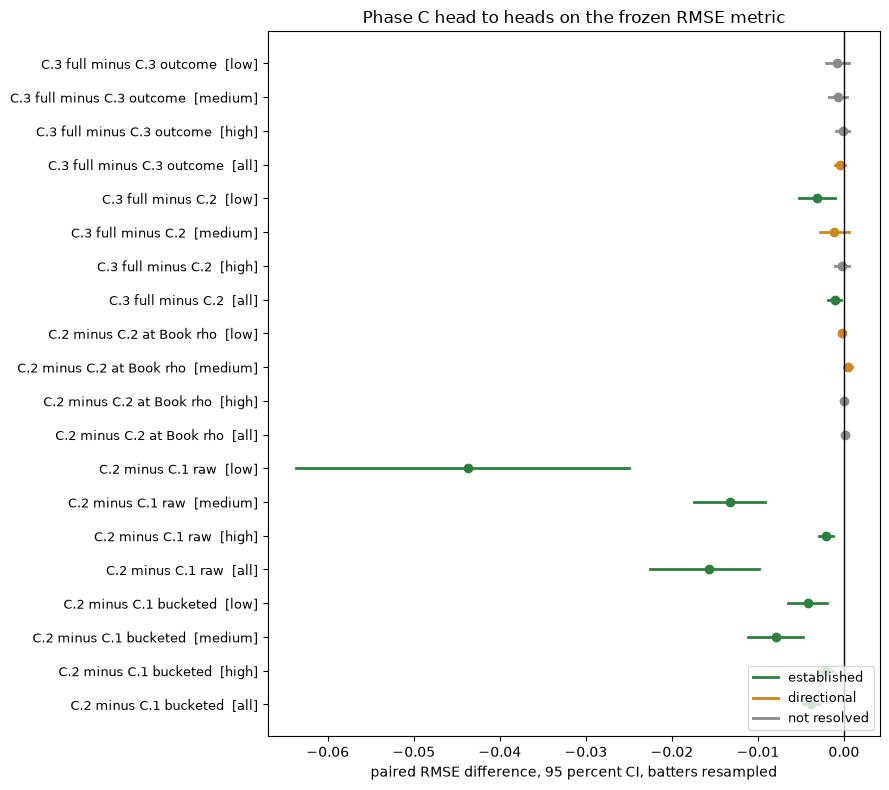

In [11]:
VERDICT_COLORS = {"established": "#2d7f3e", "directional": "#c98a1b", "not resolved": "#8a8a8a"}

plotted = paired.sort_values(["comparison", "stratum"], ascending=[True, False]).reset_index(drop=True)
figure, axis = plt.subplots(figsize=(9, 8))
for position, row in plotted.iterrows():
    axis.plot([row["ci_low"], row["ci_high"]], [position, position],
              color=VERDICT_COLORS[row["verdict"]], lw=2)
    axis.plot(row["rmse_difference"], position, "o", color=VERDICT_COLORS[row["verdict"]], ms=6)
axis.axvline(0, color="black", lw=1)
axis.set_yticks(range(len(plotted)))
axis.set_yticklabels([f"{row.comparison}  [{row.stratum}]" for row in plotted.itertuples()], fontsize=9)
axis.set_xlabel("paired RMSE difference, 95 percent CI, batters resampled")
axis.set_title("Phase C head to heads on the frozen RMSE metric")
axis.legend(handles=[plt.Line2D([], [], color=color, lw=2, label=name)
                     for name, color in VERDICT_COLORS.items()], loc="lower right", fontsize=9)
figure.tight_layout()
plt.show()

## Paired ordering head to heads
The same treatment applied to rank correlation, which had previously been reported without an
interval. Positive favours the first model named. The low stratum result overturns the phase's
former headline that C.2 orders low exposure hitters better than C.3.

In [12]:
rank_paired = load("c_rank_paired.csv")
rank_paired["verdict"] = rank_paired.apply(verdict, axis=1)
rank_paired["stratum"] = pd.Categorical(rank_paired["stratum"], STRATUM_ORDER, ordered=True)
rank_paired.sort_values(["comparison", "stratum"])[
    ["comparison", "stratum", "n_batters", "rank_a", "rank_b", "rank_difference", "ci_low",
     "ci_high", "favours_a_share", "verdict"]].round(4).set_index(["comparison", "stratum"])

n_batters  rank_a  rank_b  rank_difference  ci_low  ci_high  favours_a_share       verdict
comparison            stratum                                                                                            
c2_vs_c1_bucketed     low            239  0.1140  0.0157           0.0983 -0.0111   0.2156           0.9575   directional
                      medium         238  0.2509  0.1521           0.0988  0.0375   0.1667           0.9995   established
                      high           318  0.4850  0.4424           0.0426  0.0203   0.0670           0.9995   established
                      all            604  0.3283  0.2581           0.0702  0.0371   0.1037           1.0000   established
c2_vs_c1_raw          low            239  0.1140  0.1138           0.0002 -0.0902   0.1039           0.5185  not resolved
                      medium         238  0.2509  0.1544           0.0965  0.0337   0.1648           0.9980   established
                      high           318  0.4850  0.4446           0.0404  0.0181   0.0645           0.9995   established
                      all            604  0.3283  0.2762           0.0521  0.0152   0.0872           0.9985   established
c3_full_vs_c2         low            239  0.1288  0.1140           0.0148 -0.0949   0.1215           0.6045  not resolved
                      medium         238  0.2574  0.2509           0.0065 -0.0665   0.0766           0.5655  not resolved
                      high           318  0.4979  0.4850           0.0128 -0.0181   0.0438           0.7910  not resolved
                      all            604  0.3704  0.3283           0.0421  0.0030   0.0815           0.9850   established
c3_full_vs_c3_outcome low            239  0.1288  0.1107           0.0180 -0.0730   0.1084           0.6645  not resolved
                      medium         238  0.2574  0.2113           0.0461 -0.0052   0.0981           0.9585   directional
                      high           318  0.4979  0.4811           0.0168 -0.0141   0.0468           0.8625  not resolved
                      all            604  0.3704  0.3445           0.0260 -0.0013   0.0531           0.9660   directional

## Exposure talent correlation
Prior exposure correlates with talent, so any model with a single exchangeable prior mean must
over predict low exposure hitters. C.2 is structurally unable to express this and C.3 has
exposure as a feature.

In [13]:
load("c2_exposure_talent_correlation.csv").round(3)

,vs_hand,n_groups,corr_prior_pa_vs_observed_woba
0,L,551,0.236
1,R,598,0.244


## Prediction bias by stratum
Mean prediction minus mean actual, PA weighted. Positive means the model predicts a higher wOBA
than the hitters actually produced.

In [14]:
bias = load("c_prediction_bias.csv")
bias["model"] = pd.Categorical(bias["model"], MODEL_ORDER, ordered=True)
bias["stratum"] = pd.Categorical(bias["stratum"], ["low", "medium", "high"], ordered=True)
bias.pivot(index="model", columns="stratum", values="bias").round(4)

stratum,low,medium,high
model,,,
no_info_league_average,0.0231,0.0135,-0.0038
c1_raw,0.0017,0.0037,0.0112
c1_bucketed,0.0193,0.0095,0.0112
c2_bivariate,0.0188,0.0091,0.0088
c2_book_rho_reference,0.0184,0.0087,0.0088
c3_gbm_outcome,0.0048,0.0096,0.0059
c3_gbm_full,0.0082,0.0116,0.0089


## Oracle level correction bound
Recenters both models per stratum using the held out actuals, which peeks at the answer key and
is therefore an upper bound rather than a model. What survives the recentering is ordering
skill and what disappears was level error.

In [15]:
oracle = load("c3_vs_c2_oracle_debiased.csv").set_index("stratum")
reported = load("c3_vs_c2_paired.csv").set_index("stratum")
level_correction = pd.DataFrame({
    "reported_difference": reported["rmse_difference"],
    "oracle_debiased_difference": oracle["rmse_difference"],
    "oracle_ci_low": oracle["ci_low"],
    "oracle_ci_high": oracle["ci_high"],
}).loc[STRATUM_ORDER]
level_correction["share_that_is_level"] = (
    1 - level_correction["oracle_debiased_difference"] / level_correction["reported_difference"])
level_correction.round(5)

,reported_difference,oracle_debiased_difference,oracle_ci_low,oracle_ci_high,share_that_is_level
stratum,,,,,
low,-0.00308,-0.00074,-0.00241,0.00104,0.76087
medium,-0.00113,-0.00168,-0.00332,0.00003,-0.48896
high,-0.00024,-0.00026,-0.00102,0.00051,-0.09397
all,-0.00109,-0.00068,-0.00136,0.00003,0.37737


## Level share across the eval filter sweep
The level share is a point on a curve rather than a constant, so it is quoted as the range
across the committed censoring sweep and never as a single figure.

In [16]:
sensitivity = load("c_min_eval_pa_sensitivity.csv")
low_stratum_share = sensitivity[sensitivity["stratum"] == "low"][["min_eval_pa", "oracle_share_level"]]
print(low_stratum_share.round(3).to_string(index=False))
print(f"low stratum level share range: {low_stratum_share['oracle_share_level'].min():.0%} "
      f"to {low_stratum_share['oracle_share_level'].max():.0%}")

 min_eval_pa  oracle_share_level
          10               0.761
          25               0.799
          50               0.567
low stratum level share range: 57% to 80%


## Predictions for hitters with no prior history
With no prior window data every C.3 feature is missing or zero, so the only feature that could
still separate these rows is the pitcher hand indicator. This decodes eight such hitters against
the source and counts how many distinct values each model emits.

In [17]:
decode = load("c_decode_sample.csv")
display(decode[["batter", "p_throws", "prior_pa", "stratum", "pa", "woba", "c2_bivariate",
                "c1_bucketed", "c3_gbm_outcome", "c3_gbm_full"]].round(4))
print("distinct predictions across these rows")
print(decode[["c2_bivariate", "c1_bucketed", "c3_gbm_outcome", "c3_gbm_full"]].nunique())

,batter,p_throws,prior_pa,stratum,pa,woba,c2_bivariate,c1_bucketed,c3_gbm_outcome,c3_gbm_full
0,640902,L,0.0,low,11,0.2405,0.3289,0.3181,0.2991,0.3036
1,640902,R,0.0,low,29,0.2073,0.3097,0.3141,0.2984,0.3036
2,642197,L,0.0,low,34,0.3114,0.3289,0.3181,0.2991,0.3036
3,642197,R,0.0,low,14,0.1122,0.3097,0.3141,0.2984,0.3036
4,660844,L,0.0,low,32,0.2239,0.3169,0.3181,0.2991,0.3036
5,660844,R,0.0,low,54,0.3177,0.3047,0.3141,0.2984,0.3036
6,665052,L,0.0,low,21,0.3404,0.2944,0.3181,0.2991,0.3036
7,665052,R,0.0,low,68,0.3354,0.3241,0.3141,0.2984,0.3036


distinct predictions across these rows
c2_bivariate      6
c1_bucketed       2
c3_gbm_outcome    2
c3_gbm_full       1
dtype: int64


## C.3 gain importance
In sample gain importance, for interpretation only, since the ablation is the evidence. The
zero gain list is the mechanism behind the collapse above.

In [18]:
importance = load("c3_feature_importance.csv")
display(importance.head(8).round(4))
print("features with exactly zero gain:", importance[importance["gain"] == 0]["feature"].tolist())

,feature,gain
0,own_woba,0.3302
1,ev_mean,0.1687
2,pooled_ev_mean,0.1182
3,pooled_pitches,0.0911
4,total_pa,0.0864
5,la_mean,0.0809
6,own_pitches,0.0800
7,pooled_whiff_rate,0.0765


features with exactly zero gain: ['bats_switch', 'vs_lhp']


## Fitted C.2 prior against The Book
C.2 shrinks the two platoon sides jointly rather than the split, which is the same model in
rotated coordinates but identifiable where the split form is not. rho is estimated only on
hitters with at least 50 PA against both hands, since restricting a correlation to the durable
subpopulation is a milder assumption than restricting a variance.

In [19]:
load("c2_prior_parameters.csv")[
    ["batter_type", "vs_hand", "n_hitters", "mu", "tau", "sigma2_within_pa", "n_star_rate",
     "rho", "rho_ci_low", "rho_ci_high", "rho_bootstrap_share_at_bound", "n_rho_hitters",
     "n_star_split_implied", "book_split_constant", "book_implied_rho"]].round(4)

,batter_type,vs_hand,n_hitters,mu,tau,sigma2_within_pa,n_star_rate,rho,rho_ci_low,rho_ci_high,rho_bootstrap_share_at_bound,n_rho_hitters,n_star_split_implied,book_split_constant,book_implied_rho
0,L,L,321,0.2944,0.0317,0.2348,234.0907,0.6522,0.3836,0.9018,0.0050,177,320.6538,1000.0,0.887
1,L,R,321,0.3241,0.0331,0.2689,244.8108,0.6522,0.3836,0.9018,0.0050,177,320.6538,1000.0,0.887
2,R,L,536,0.3289,0.0287,0.2769,335.4125,0.7187,0.4787,0.9866,0.0225,354,562.9819,2200.0,0.949
3,R,R,536,0.3097,0.0303,0.2603,283.9372,0.7187,0.4787,0.9866,0.0225,354,562.9819,2200.0,0.949
4,S,L,98,0.3169,0.0341,0.2559,219.5002,0.7127,0.0926,0.9990,0.2000,71,435.0818,NaN,0.949
5,S,R,98,0.3047,0.0281,0.2543,321.0560,0.7127,0.0926,0.9990,0.2000,71,435.0818,NaN,0.949


## Label shuffle null
Re-runs the same fitting procedure with the hitter to target link destroyed. If the pipeline
could manufacture skill from leakage or from the fitting procedure itself, a shuffled fit would
score competitively.

In [20]:
shuffle_null = load("c3_shuffle_null.csv")
shuffle_null["stratum"] = pd.Categorical(shuffle_null["stratum"], STRATUM_ORDER, ordered=True)
shuffle_null.sort_values("stratum").round(5)

,stratum,n_seeds,mean_difference,min_difference,max_difference,n_null_fits_beating_real
2,low,5,0.00238,0.00214,0.00255,0
3,medium,5,0.00163,0.00158,0.00168,0
1,high,5,0.00684,0.00664,0.00698,0
0,all,5,0.00465,0.00456,0.00472,0


## Eval filter sensitivity
Re-scores the headline C.3 versus C.2 comparison across the committed sweep, so any conclusion
that depends on the censoring choice is visible rather than assumed away.

In [21]:
sensitivity["stratum"] = pd.Categorical(sensitivity["stratum"], STRATUM_ORDER, ordered=True)
sensitivity["rmse_established"] = (sensitivity["rmse_ci_high"] < 0) | (sensitivity["rmse_ci_low"] > 0)
sensitivity["rank_established"] = (sensitivity["rank_ci_high"] < 0) | (sensitivity["rank_ci_low"] > 0)
sensitivity.sort_values(["stratum", "min_eval_pa"])[
    ["stratum", "min_eval_pa", "n_hitters", "rmse_difference", "rmse_ci_low", "rmse_ci_high",
     "rmse_established", "rank_difference", "rank_established", "bias_c2", "bias_c3"]].round(5).set_index(
    ["stratum", "min_eval_pa"])

n_hitters  rmse_difference  rmse_ci_low  rmse_ci_high  rmse_established  rank_difference  rank_established  bias_c2  bias_c3
stratum min_eval_pa                                                                                                                              
low     10                 380         -0.00308     -0.00520      -0.00102              True          0.01479             False  0.01875  0.00818
        25                 294         -0.00267     -0.00492      -0.00048              True         -0.06786             False  0.01682  0.00636
        50                 194         -0.00251     -0.00560       0.00022             False         -0.00409             False  0.01205  0.00146
medium  10                 280         -0.00113     -0.00275       0.00063             False          0.00649             False  0.00908  0.01158
        25                 250         -0.00106     -0.00283       0.00072             False         -0.00262             False  0.00838  0.01098
        50                 210         -0.00131     -0.00328       0.00058             False         -0.01944             False  0.00752  0.01009
high    10                 489         -0.00024     -0.00102       0.00054             False          0.01282             False  0.00883  0.00890
        25                 469         -0.00026     -0.00103       0.00057             False          0.01437             False  0.00853  0.00860
        50                 444         -0.00026     -0.00106       0.00051             False          0.00841             False  0.00821  0.00826
all     10                1149         -0.00109     -0.00186      -0.00035              True          0.04212              True      NaN      NaN
        25                1013         -0.00096     -0.00176      -0.00019              True          0.01775             False      NaN      NaN
        50                 848         -0.00091     -0.00169      -0.00011              True          0.00568             False      NaN      NaN

## What Phase C establishes
Established means paired, batter clustered, and the 95 percent interval excludes zero.

- Shrinkage is the largest step on the ladder. C.2 beats unshrunk C.1 raw by 0.0437 in the low stratum and beats bucketed C.1 by 0.0042, both in every stratum at 100 percent of draws.
- The C.1 raw pair is the one that shows what shrinkage actually fixes. C.2 wins enormously on calibration yet the two are a dead heat on low stratum ordering, difference 0.0002 with CI from -0.090 to +0.104, so in the stratum that matters the hitter's raw record already carries the order and shrinkage supplies the level. C.2 does order better than raw everywhere else, medium 0.096, high 0.040, frame wide 0.052, all with intervals excluding zero.
- Bucketing fixes the level but destroys the order, low stratum rank falling from 0.114 to 0.016, because a step function ties everyone inside a bucket. Only continuous shrinkage gets both.
- C.3 full beats C.2 on RMSE in the low stratum and frame wide, and on ordering frame wide.
- C.2 beats C.1 bucketed on ordering in the medium and high strata and frame wide.
- The result is not a pipeline artifact. No shuffled fit matches the real model in any stratum.
- The RMSE headline is not an eval filter artifact. The low stratum margin holds its sign and magnitude across a 3x swing in censoring, and the interval excludes zero at the two lower cuts.

## What Phase C does not establish
- No ordering claim in the low stratum for any pair on the ladder. Every low stratum interval crosses zero, and the phase's former headline that C.2 orders low exposure hitters better, 0.169 against 0.102, does not survive an interval and reverses sign at the current cut. It must not be repeated.
- C.2 at the fitted rho and C.2 at The Book's published constants are indistinguishable. No interval excludes zero and the two trade places between strata, despite the parameters differing by a factor of 3 to 4.
- C.3's process features are directional only, 65 to 91 percent of draws on RMSE by stratum and 97 percent on ordering frame wide, with no interval excluding zero.
- Most of C.3's low stratum RMSE margin is level rather than ordering, 57 to 80 percent across the committed sweep. Quote the range, never a single figure.
- Platoon skill exists but is not tightly resolved, rho 0.65 for left handed batters and 0.72 for right handed. Switch hitters are effectively unidentified, interval from 0.09 to 0.999 with a fifth of draws pinned at the bound.

## What Phase C leaves open
- The step from C.2 to C.3 outcome has no paired interval, so the null previously reported for it is not supported by a committed test. From the absolute table the point difference is 0.0023 in the low stratum in C.3 outcome's favour, which is about three quarters of the full C.2 to C.3 full margin. Until an interval exists, neither a null nor a win can be claimed for that rung.
- No paired test exists against the Book rho reference for C.3 or Phase D, only for C.2. Frozen rule 1's named empirical Bayes incumbent has been matched by C.2, not cleared by the model that will be compared against it.
- C.3 emits one constant for nearly every hitter with no prior history, because the pitcher hand indicator carries zero gain. Those rows are about 43 percent of the low stratum, which is both the mechanism behind the oracle result and the reason low stratum ordering is weak for every model. C.3's stated hand interaction rationale is contradicted by its own importance table and is not yet corrected in the module.
- The eval filter still removes 18 percent of the low stratum and the dropped hitters are the worse ones in every stratum, so every model's level is flattered and no threshold removes that.
- B.2's six flagged context features are undecided, see notebook 02, and would enter Phase D silently.
- The enrichment of C.3's context slices to velocity band, location zone and hand by pitch group is proposed and unbuilt.

## The Phase D gate
- The RMSE bar can be set today from C.3 full: 0.05868 low and 0.04634 frame wide on raw PA weighted RMSE, 0.02894 low and 0.02486 frame wide deconvolved, skill 0.391 low and 0.460 frame wide.
- The rank bar cannot be set from C.2's 0.169. That number is at the superseded eval cut and the comparison it came from is not resolved at any cut. A low exposure ordering gate needs a section 5.2 metric amendment first, since the instability is a metric property rather than a threshold choice.
- Phase D's margin must be run through the same oracle level diagnostic. If it turns out to be the same exposure conditional level effect, an exposure conditional prior mean has to be built for C.2 before any comparison is claimed.